# Pattern Recognition - Machine Learning Project2
# Θεοφάνης Μπαρμπαρόσος - 1115202200107

### Dependencies

In [1]:
%pip install matplotlib
%pip install numpy
%pip install torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Randomness and reproducibility

In [2]:
import numpy as np, random, torch
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### EDA (Exploratory Data Analysis)

In [3]:
# General settings for plots

import matplotlib.pyplot as plt

# white background (general)
plt.rcParams['figure.facecolor'] = 'white'
# white background (inside plot)
plt.rcParams['axes.facecolor'] = 'white'
# white background also when saving plots
plt.rcParams['savefig.facecolor'] = 'white'

Number of classes: 4

- Baroque: 1350  samples
- Impressionism: 1350  samples
- Cubism: 1350  samples
- Abstract_Expressionism: 1350  samples

Total: 5400 samples


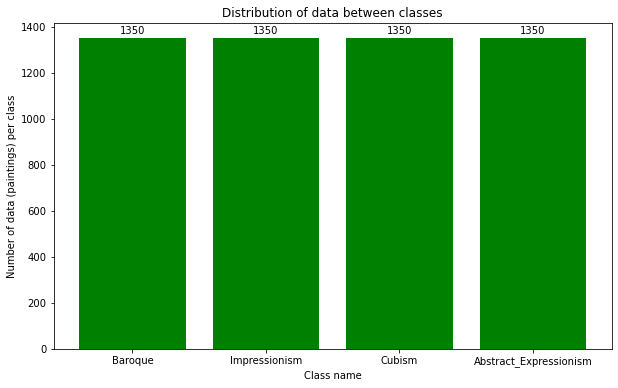

In [4]:
data = np.load('wikiart_hw2.npz')
X = data["X"]
Y = data["y"]
class_names = data["class_names"]

counts = {}
for i in range(4):
    counts[class_names[i]] = np.sum(Y == i)


print(f"Number of classes: {len(class_names)}\n")

for class_name in class_names:
    print(f"- {class_name}: {counts[class_name]}  samples")
print(f"\nTotal: {sum(counts.values())} samples")

plt.figure(figsize=(10,6))
plt.bar(counts.keys(), counts.values(), color='green')
plt.title("Distribution of data between classes")
plt.xlabel("Class name")
plt.ylabel("Number of data (paintings) per class")
plt.bar_label(plt.bar(counts.keys(), counts.values(), color='green'), padding=3)
plt.show()

### Device selection

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Creating tensors with data

In [6]:
# loading data into tensors

x_tensor = torch.tensor(X, dtype=torch.float32) / 255.0
x_tensor = x_tensor.permute(0, 3, 1, 2)

y_tensor = torch.tensor(Y, dtype=torch.int64)

print(f"x tensor: {x_tensor.shape}")
print(f"y tensor: {y_tensor.shape}")

x tensor: torch.Size([5400, 3, 32, 32])
y tensor: torch.Size([5400])


### Train-Val-Test split

Train split: x:torch.Size([3200, 3, 32, 32]) y:torch.Size([3200])
  - Baroque: 800
  - Impressionism: 800
  - Cubism: 800
  - Abstract_Expressionism: 800
Val split:   x:torch.Size([800, 3, 32, 32]) y:torch.Size([800])
  - Baroque: 200
  - Impressionism: 200
  - Cubism: 200
  - Abstract_Expressionism: 200
Test split:  x:torch.Size([1400, 3, 32, 32]) y:torch.Size([1400])
  - Baroque: 350
  - Impressionism: 350
  - Cubism: 350
  - Abstract_Expressionism: 350


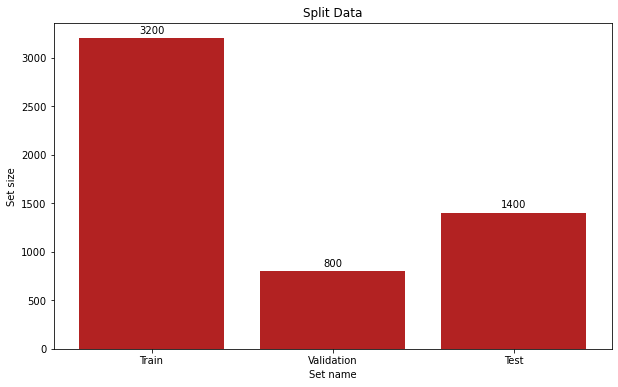

In [7]:
from sklearn.model_selection import train_test_split

# 1st split to create training data
x_train, x_temp, y_train, y_temp = train_test_split(x_tensor, y_tensor, test_size=0.407407407, random_state=SEED, stratify=y_tensor)

# 2nd split to create validation and test data
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.63636363, random_state=SEED, stratify=y_temp)

print(f"Train split: x:{x_train.shape} y:{y_train.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_train==i).sum().item()}")
print(f"Val split:   x:{x_val.shape} y:{y_val.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_val==i).sum().item()}")
print(f"Test split:  x:{x_test.shape} y:{y_test.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_test==i).sum().item()}")

plt.figure(figsize=(10, 6))
plt.bar(["Train", "Validation", "Test"], [x_train.shape[0], x_val.shape[0], x_test.shape[0]], color='firebrick')
plt.title("Split Data")
plt.xlabel("Set name")
plt.ylabel("Set size")
plt.bar_label(plt.bar(["Train", "Validation", "Test"], [x_train.shape[0], x_val.shape[0], x_test.shape[0]], color='firebrick'), padding=3)
plt.show()

### Datasets and dataloaders

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 16

# datasets(for dataloaders)
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

# necessary for reproducibility
# (apparently if this generator isn't used in the training dataloader, reproducibility isn't guaranteed)
g = torch.Generator()
g.manual_seed(SEED)

# dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# debugging
print(f"Train batches: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")

Train batches: 200
Validation batches: 50
Test batches: 88


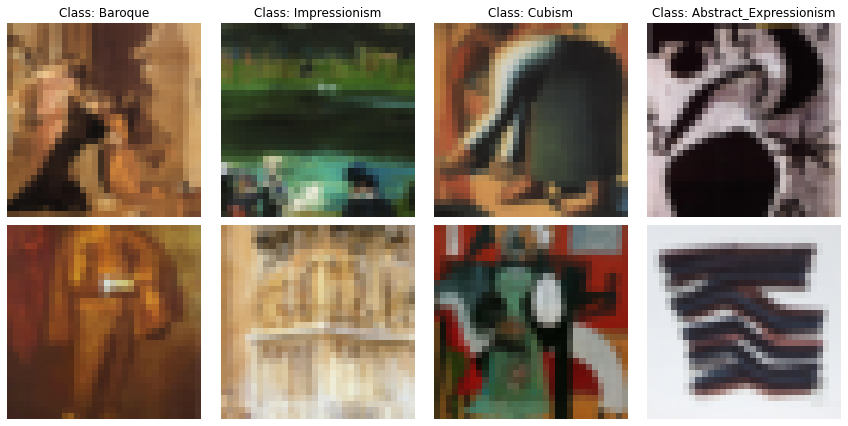

In [9]:
# a few samples

samples_per_class = {0: [], 1: [], 2: [], 3: []}

for i in range(len(y_tensor)):
    label = y_tensor[i].item()
    if len(samples_per_class[label]) < 2:
        samples_per_class[label].append(x_tensor[i])
    if all(len(images) == 2 for images in samples_per_class.values()):
        break

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for class_idx in range(4):
    for sample_idx in range(2):
        img_tensor = samples_per_class[class_idx][sample_idx]
        img_np = img_tensor.permute(1, 2, 0).numpy()
        if img_np.max() > 1.0:
            img_np = img_np / 255.0
        img_np = np.clip(img_np, 0, 1)
        ax = axes[sample_idx, class_idx]
        ax.imshow(img_np)
        if sample_idx == 0:
            ax.set_title(f"Class: {class_names[class_idx]}")
        ax.axis("off")

plt.tight_layout()
plt.show()

## Q0.1

### Training-Evaluation functions

In [10]:
import torch.nn as nn
from sklearn.metrics import f1_score, confusion_matrix

class baseline_FNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.linear_relu_stack = nn.Sequential(
            nn.Linear(in_features=3*32*32, out_features=512),
            nn.ReLU(),
            nn.Linear(in_features=512, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=4)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # forward pass
        logits = model(images)
        # loss calculation
        loss = criterion(logits, labels)
        # backward pass
        loss.backward()
        # weights update
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            images = images.to(device)
            labels = labels.to(device)

            # forward pass
            logits = model(images)
            # losss calculation
            loss = criterion(logits, labels)

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples
    epoch_f1_macro = f1_score(all_labels, all_preds, average='macro')
    epoch_loss_cm = confusion_matrix(all_labels, all_preds)
    
    return epoch_loss, epoch_acc, epoch_f1_macro, epoch_loss_cm


### Training

In [11]:
from torch.optim import Adam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = baseline_FNN().to(device)
EPOCHS = 30
LEARNING_RATE = 0.001
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

best_f1_val = -1
best_model_path = "best_baseline_fnn.pth"

print("Starting Training...\n")

for epoch in range(EPOCHS):
    # train (adjusting weights)
    train_loss, train_acc = train_one_epoch(model, train_dataloader, optimizer, criterion)

    # evaluate
    val_loss, val_acc, val_f1, val_cm = evaluate(model, val_dataloader, criterion)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    if val_f1>best_f1_val:
        best_f1_val = val_f1
        torch.save(model.state_dict(), best_model_path)

    # current epoch results
    print(f"Epoch [{epoch+1}/{EPOCHS}]  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
    print("-" * 100)

print("Training Complete!")

Using device: cpu
Starting Training...

Epoch [1/30]  Train Loss: 1.3827 | Train Acc: 30.50%  Val Loss:   1.3418 | Val Acc:   38.62% | Val F1: 0.3178
----------------------------------------------------------------------------------------------------
Epoch [2/30]  Train Loss: 1.3152 | Train Acc: 37.44%  Val Loss:   1.2974 | Val Acc:   41.38% | Val F1: 0.3883
----------------------------------------------------------------------------------------------------
Epoch [3/30]  Train Loss: 1.2749 | Train Acc: 41.03%  Val Loss:   1.2789 | Val Acc:   42.75% | Val F1: 0.3749
----------------------------------------------------------------------------------------------------
Epoch [4/30]  Train Loss: 1.2460 | Train Acc: 42.69%  Val Loss:   1.3487 | Val Acc:   37.88% | Val F1: 0.3528
----------------------------------------------------------------------------------------------------
Epoch [5/30]  Train Loss: 1.2343 | Train Acc: 43.66%  Val Loss:   1.2785 | Val Acc:   42.50% | Val F1: 0.3839
------

### Training on CPU

In [12]:
import time

device = torch.device("cpu")

print(">>> Training started using CPU...")

model_cpu = baseline_FNN().to(device)
optimizer_cpu = Adam(model_cpu.parameters(), lr=LEARNING_RATE)

start_time_cpu = time.time()
for epoch in range(EPOCHS):
    train_one_epoch(model_cpu, train_dataloader, optimizer_cpu, criterion)
end_time_cpu = time.time()
cpu_time = end_time_cpu - start_time_cpu
print(f">>> CPU training complete! Time: {cpu_time:.2f} seconds")

>>> Training started using CPU...
>>> CPU training complete! Time: 83.07 seconds


### Training on GPU

In [13]:


if torch.cuda.is_available():
    device = torch.device("cuda")

    print(">>> Training started using GPU...")

    model_gpu = baseline_FNN().to(device)
    optimizer_gpu = Adam(model_gpu.parameters(), lr=LEARNING_RATE)

    start_time_gpu = time.time()
    for epoch in range(EPOCHS):
        train_one_epoch(model_gpu, train_dataloader, optimizer_gpu, criterion)
    end_time_gpu = time.time()
    gpu_time = end_time_gpu - start_time_gpu
    print(f">>> GPU training complete! Time: {gpu_time:.2f} seconds")

    # comparison
    speedup = cpu_time / gpu_time
    quicker = "GPU" if speedup>1 else "CPU"
    slower = "CPU" if speedup>1 else "GPU"
    print(quicker + f" was {speedup:.4f} times quicker than the " + slower)

else:
    print("No GPU (CUDA) is available for training.")

# for safety
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

No GPU (CUDA) is available for training.


### Best model evaluation on test set

In [14]:
best_model = baseline_FNN().to(device)

best_model.load_state_dict(torch.load("best_baseline_fnn.pth"))

test_loss, test_acc, test_f1, test_cm = evaluate(best_model, test_dataloader, criterion)

print("=======  Baseline FNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test F1-macro: {test_f1}")
print(f"Test Confusion matrix:")
for row in test_cm:
    print(row)

=======  Baseline FNN model evaluation on TEST SET  =======
Test Loss: 1.1691565336499896
Test Accuracy: 0.4878571428571429
Test F1-macro: 0.4895695016825665
Test Confusion matrix:
[207  26  76  41]
[ 27 181  90  52]
[ 64  63 121 102]
[ 66  30  80 174]


### Learning curves (Loss and F1-macro)

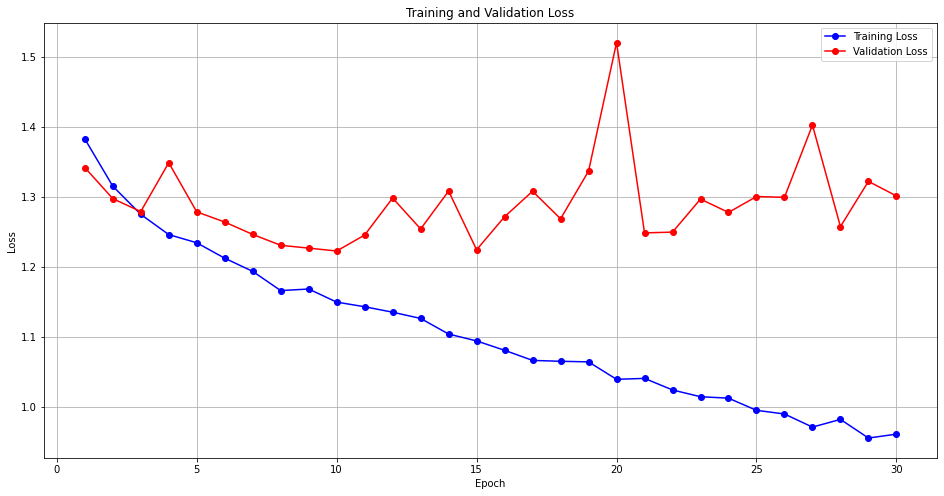

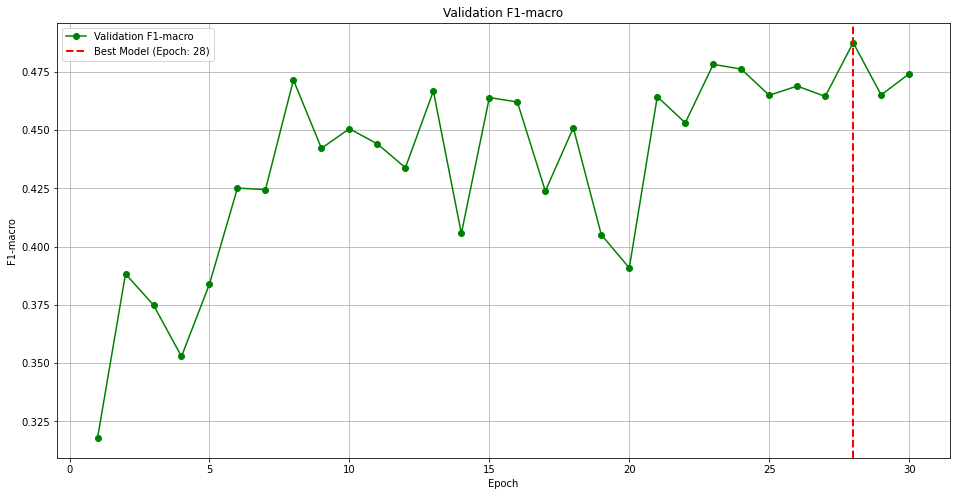

In [15]:
# loss
plt.figure(figsize=(16, 8))
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], 'bo-', label='Training Loss')
plt.plot(range(1, len(history['val_loss'])+1), history['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# f1-macro
plt.figure(figsize=(16, 8))
plt.plot(range(1, len(history['val_f1'])+1), history['val_f1'], 'go-', label='Validation F1-macro')
best_epoch = history['val_f1'].index(max(history['val_f1'])) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch: {best_epoch})')
plt.title('Validation F1-macro')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.legend()
plt.grid(True)